In [1]:
import pandas as pd
import numpy as np

In [11]:
results = pd.read_csv('../data/raw/results.csv')
elo = pd.read_csv('../data/raw/elo_ratings.csv')
shootouts = pd.read_csv('../data/raw/shootouts.csv')
goalscorers = pd.read_csv('../data/raw/goalscorers.csv')
fixtures = pd.read_csv('../data/raw/wc2026_fixtures.csv')
schedule = pd.read_csv('../data/raw/FIFA2026_schedule.csv')

In [12]:
print("Results:", results.shape)
print("Elo:", elo.shape)
print("Shootouts:", shootouts.shape)
print("Goalscorers:", goalscorers.shape)
print("Fixtures:", fixtures.shape)
print("Schedule:", schedule.shape)

Results: (49472, 9)
Elo: (4683, 23)
Shootouts: (678, 5)
Goalscorers: (47601, 8)
Fixtures: (104, 6)
Schedule: (104, 5)


In [13]:
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [14]:
elo.head()

,year,snapshot_date,country,rank,country_code,rating,rank_max,rating_max,rank_avg,rating_avg,...,matches_home,matches_away,matches_neutral,wins,losses,draws,goals_for,goals_against,confederation,is_host
0,1901,1901-12-31,England,1,EN,2013,1,2079,2,1989,...,38,35,0,46,16,11,262,102,UEFA,0
1,1901,1901-12-31,Scotland,2,SQ,1973,1,2104,1,2018,...,37,37,0,53,9,12,277,101,UEFA,0
2,1902,1902-12-31,Argentina,1,AR,2021,1,2021,1,2021,...,0,1,0,1,0,0,6,0,CONMEBOL,0
3,1902,1902-12-31,England,2,EN,1995,1,2079,2,1989,...,39,38,0,47,16,14,266,105,UEFA,0
4,1902,1902-12-31,Scotland,3,SQ,1983,1,2104,1,2017,...,39,40,0,56,9,14,293,106,UEFA,0


In [15]:
results.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='object')

In [16]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49472 entries, 0 to 49471
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49472 non-null  object 
 1   home_team   49472 non-null  object 
 2   away_team   49472 non-null  object 
 3   home_score  49400 non-null  float64
 4   away_score  49400 non-null  float64
 5   tournament  49472 non-null  object 
 6   city        49472 non-null  object 
 7   country     49472 non-null  object 
 8   neutral     49472 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


In [17]:
results['date'] = pd.to_datetime(results['date'])
shootouts['date'] = pd.to_datetime(shootouts['date'])
goalscorers['date'] = pd.to_datetime(goalscorers['date'])

In [18]:
results['year'] = results['date'].dt.year
results['month'] = results['date'].dt.month

In [19]:
results.isnull().sum()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
year           0
month          0
dtype: int64

In [20]:
elo.isnull().sum()

year               0
snapshot_date      0
country            0
rank               0
country_code       0
rating             0
rank_max           0
rating_max         0
rank_avg           0
rating_avg         0
rank_min           0
rating_min         0
matches_total      0
matches_home       0
matches_away       0
matches_neutral    0
wins               0
losses             0
draws              0
goals_for          0
goals_against      0
confederation      0
is_host            0
dtype: int64

In [21]:
results.duplicated().sum()

0

In [22]:
results = results.drop_duplicates()

In [23]:
results.describe()

,date,home_score,away_score,year,month
count,49472,49400.000000,49400.000000,49472.000000,49472.000000
mean,1994-05-21 09:58:14.631306624,1.757247,1.181862,1993.855999,6.902228
min,1872-11-30 00:00:00,0.000000,0.000000,1872.000000,1.000000
25%,1980-09-06 00:00:00,1.000000,0.000000,1980.000000,4.000000
50%,2000-07-15 00:00:00,1.000000,1.000000,2000.000000,7.000000
75%,2013-07-14 00:00:00,2.000000,2.000000,2013.000000,10.000000
max,2026-06-27 00:00:00,31.000000,21.000000,2026.000000,12.000000
std,NaN,1.774311,1.402067,25.438167,3.231808


In [24]:
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'Home Win'
    elif row['home_score'] < row['away_score']:
        return 'Away Win'
    else:
        return 'Draw'

results['match_result'] = results.apply(get_result, axis=1)

In [25]:
results['match_result'].value_counts()

match_result
Home Win    24209
Away Win    13958
Draw        11305
Name: count, dtype: int64

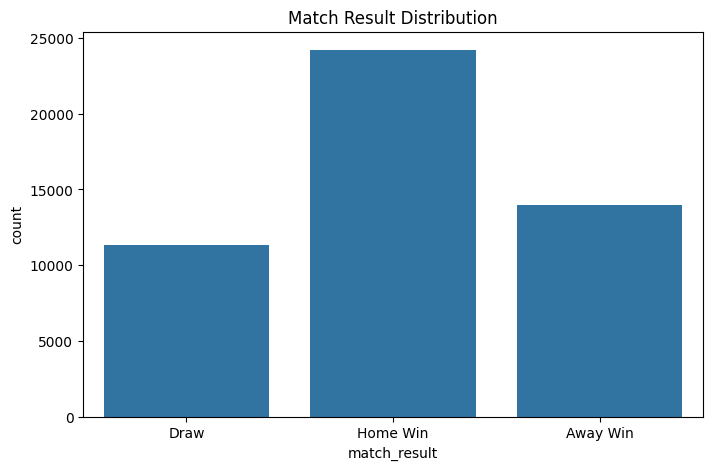

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(data=results, x='match_result')

plt.title("Match Result Distribution")
plt.show()

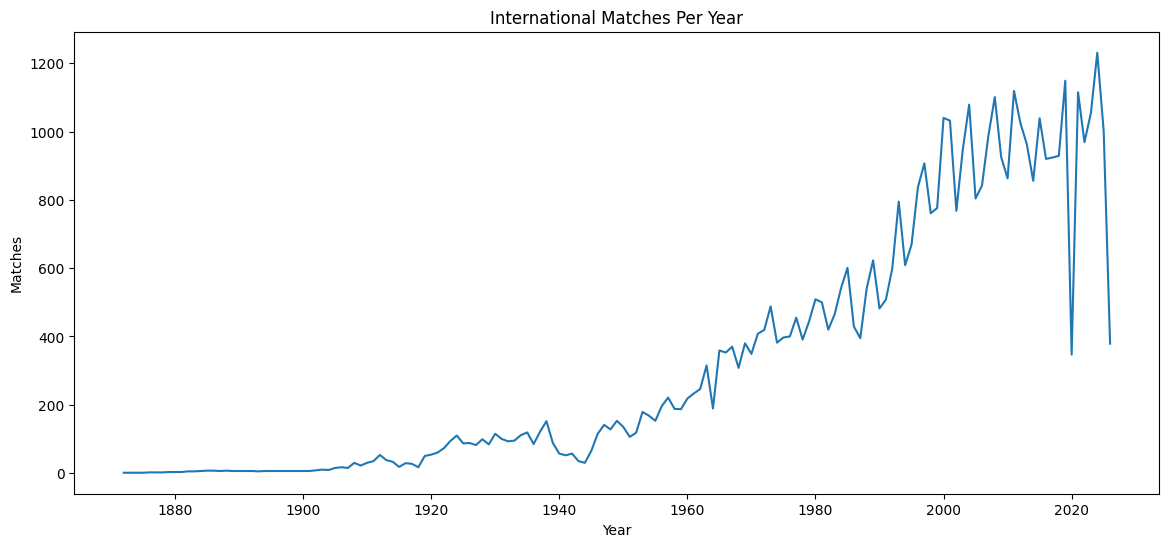

In [27]:
matches_per_year = results['year'].value_counts().sort_index()

plt.figure(figsize=(14,6))

matches_per_year.plot()

plt.title("International Matches Per Year")
plt.xlabel("Year")
plt.ylabel("Matches")

plt.show()

In [28]:
results['total_goals'] = (
    results['home_score'] + results['away_score']
)

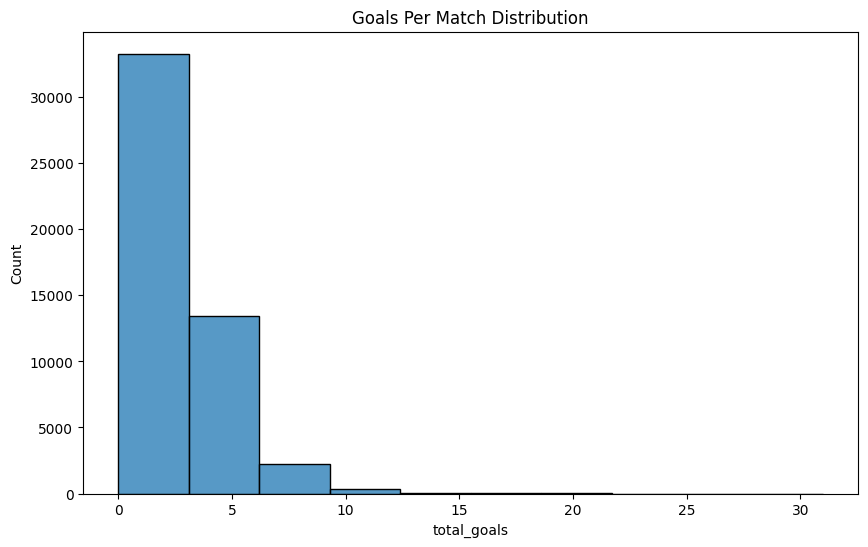

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(results['total_goals'], bins=10)

plt.title("Goals Per Match Distribution")

plt.show()

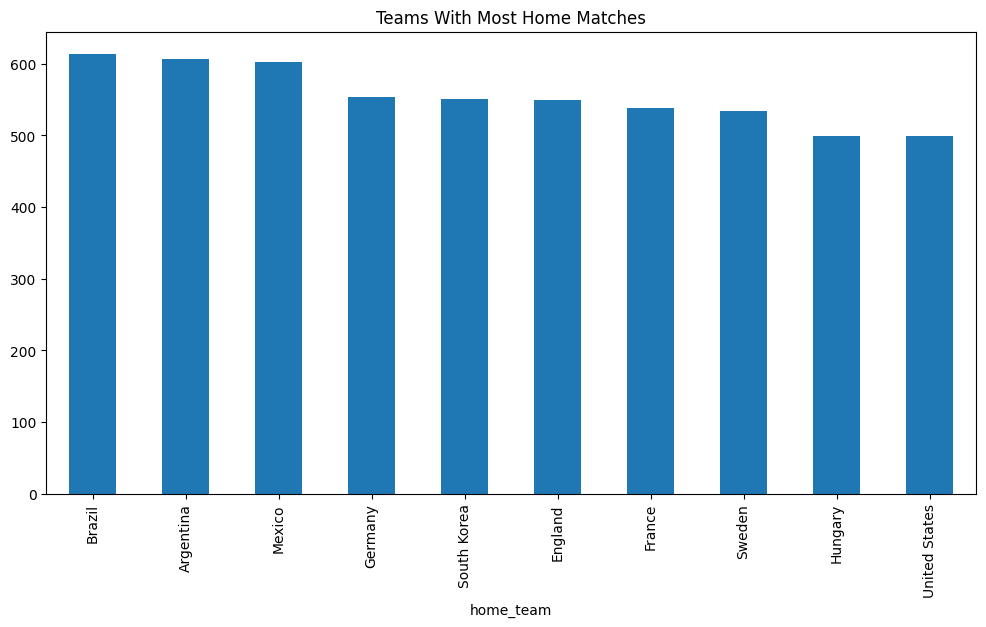

In [30]:
home_wins = results.groupby('home_team')['home_score'].count()

top_teams = home_wins.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_teams.plot(kind='bar')

plt.title("Teams With Most Home Matches")

plt.show()

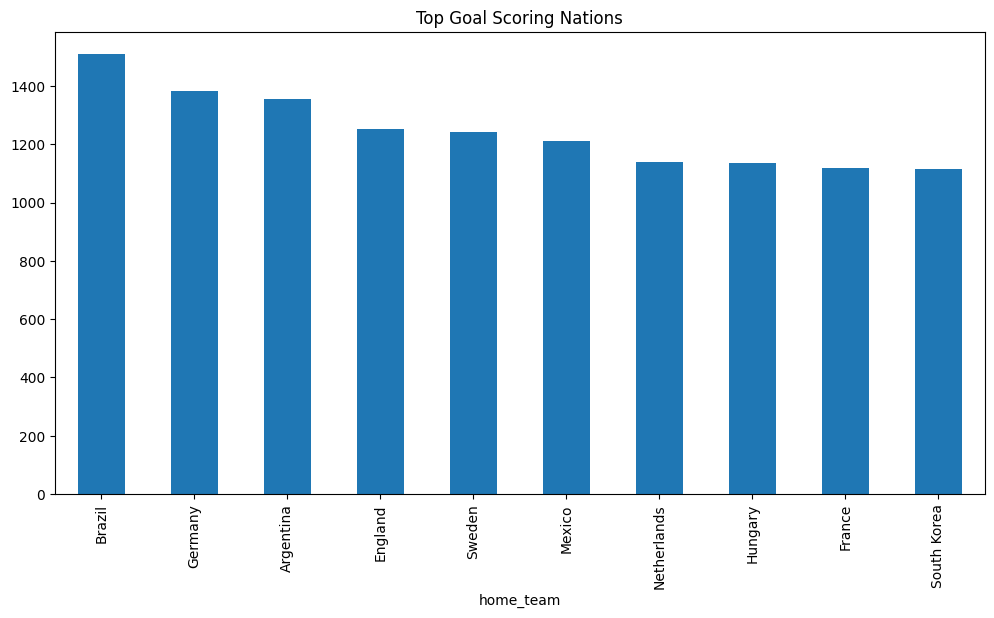

In [31]:
team_goals = (
    results.groupby('home_team')['home_score']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

team_goals.plot(kind='bar')

plt.title("Top Goal Scoring Nations")

plt.show()

In [32]:
elo.head()

,year,snapshot_date,country,rank,country_code,rating,rank_max,rating_max,rank_avg,rating_avg,...,matches_home,matches_away,matches_neutral,wins,losses,draws,goals_for,goals_against,confederation,is_host
0,1901,1901-12-31,England,1,EN,2013,1,2079,2,1989,...,38,35,0,46,16,11,262,102,UEFA,0
1,1901,1901-12-31,Scotland,2,SQ,1973,1,2104,1,2018,...,37,37,0,53,9,12,277,101,UEFA,0
2,1902,1902-12-31,Argentina,1,AR,2021,1,2021,1,2021,...,0,1,0,1,0,0,6,0,CONMEBOL,0
3,1902,1902-12-31,England,2,EN,1995,1,2079,2,1989,...,39,38,0,47,16,14,266,105,UEFA,0
4,1902,1902-12-31,Scotland,3,SQ,1983,1,2104,1,2017,...,39,40,0,56,9,14,293,106,UEFA,0


In [33]:
elo.columns

Index(['year', 'snapshot_date', 'country', 'rank', 'country_code', 'rating',
       'rank_max', 'rating_max', 'rank_avg', 'rating_avg', 'rank_min',
       'rating_min', 'matches_total', 'matches_home', 'matches_away',
       'matches_neutral', 'wins', 'losses', 'draws', 'goals_for',
       'goals_against', 'confederation', 'is_host'],
      dtype='object')

In [34]:
latest_elo = elo.sort_values('year').groupby('country').tail(1)

top_elo = latest_elo.sort_values(
    by='rating',
    ascending=False
).head(10)

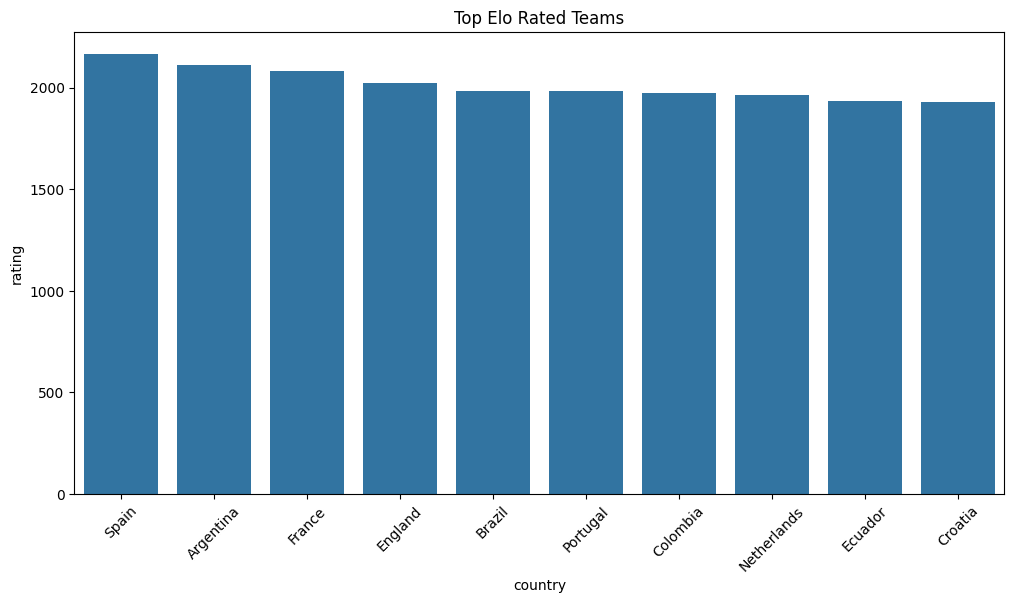

In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_elo,
    x='country',
    y='rating'
)

plt.title("Top Elo Rated Teams")

plt.xticks(rotation=45)

plt.show()

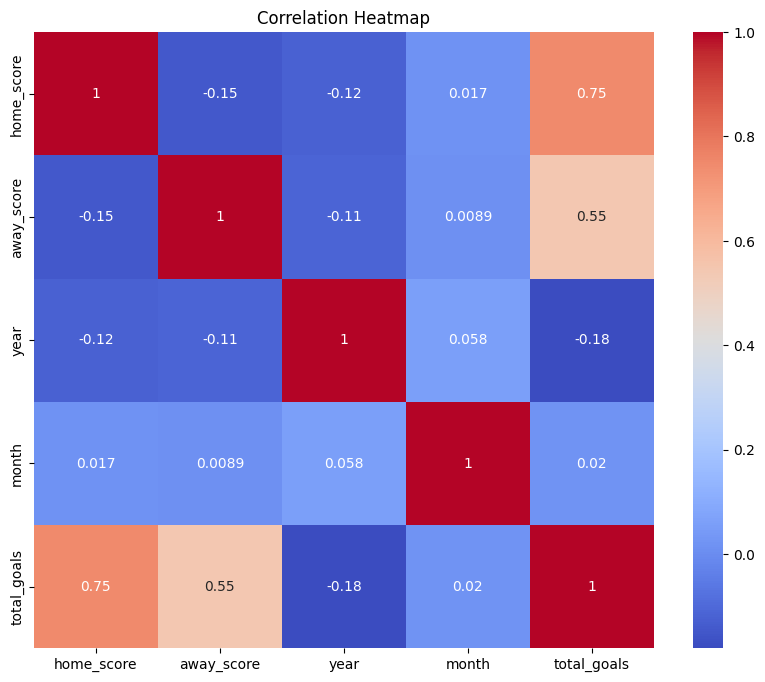

In [36]:
numeric_cols = results.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()